# Step 4 - Analyze Liquidity Migration During Roll Periods

Describe how outright volume, open interest, and calendar-spread activity change around FND using the panel from `02_clean_features.ipynb`. Results are descriptive for the available sample; they are not forecasts or cost savings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

panel = pd.read_parquet('../data/processed/zn_roll_panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel = panel.sort_values(['roll_id', 'bdays_to_fnd']).copy()
required = {'roll_id', 'bdays_to_fnd', 'next_volume_share', 'next_oi_share', 'spread_volume'}
missing = required - set(panel.columns)
if missing:
    raise ValueError(f'Missing panel columns: {sorted(missing)}')
print(f'{panel.roll_id.nunique()} rolls | {len(panel):,} daily observations')
print(f"Relative-day window: {panel.bdays_to_fnd.min()} to {panel.bdays_to_fnd.max()}")
panel.head()

27 rolls | 837 daily observations
Relative-day window: -25 to 5


,roll_id,front,next,date,bdays_to_fnd,front_volume,next_volume,total_volume,next_volume_share,front_oi,next_oi,total_oi,next_oi_share,spread_volume
0,ZNH0->ZNM0,ZNH0,ZNM0,2020-01-30,-25,2535625,634,2536259,0.000250,3803706.0,99244.0,3902950.0,0.025428,29640
1,ZNH0->ZNM0,ZNH0,ZNM0,2020-01-31,-24,2466911,1076,2467987,0.000436,3832439.0,120691.0,3953130.0,0.030530,27875
2,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-02,-23,46012,84,46096,0.001822,3889130.0,142146.0,4031276.0,0.035261,101
3,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-03,-22,2185444,663,2186107,0.000303,3879566.0,142146.0,4021712.0,0.035345,13305
4,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-04,-21,2113255,2765,2116020,0.001307,3909460.0,152276.0,4061736.0,0.037490,10403


## 1. Cross-roll migration curves

Lines show the median share across rolls; shaded areas show the 25th to 75th percentiles.

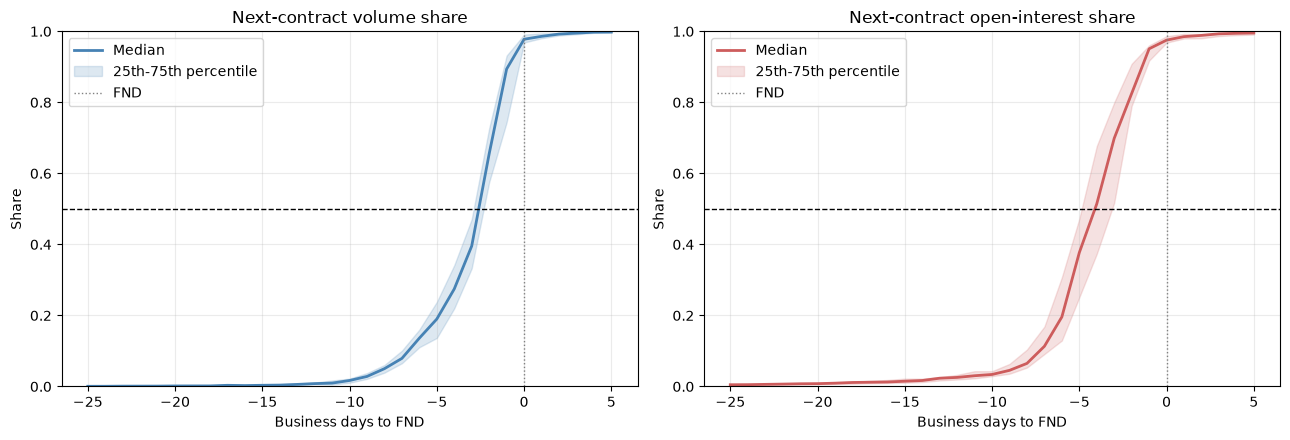

,bdays_to_fnd,volume_median,volume_q25,volume_q75,oi_median,oi_q25,oi_q75,rolls
0,-25,0.000546,0.000258,0.001036,0.004964,0.003715,0.005817,27
1,-24,0.000596,0.000413,0.001121,0.005174,0.004140,0.005871,27
2,-23,0.000968,0.000505,0.001637,0.005986,0.004703,0.007083,27
3,-22,0.001018,0.000609,0.001808,0.006770,0.005349,0.008006,27
4,-21,0.001083,0.000741,0.001647,0.007645,0.005999,0.009777,27
5,-20,0.001520,0.001294,0.002306,0.007979,0.006701,0.010661,27
6,-19,0.001607,0.001110,0.002337,0.009363,0.007458,0.011541,27
7,-18,0.001642,0.001188,0.002466,0.011317,0.007756,0.012994,27
8,-17,0.003335,0.001579,0.005032,0.012020,0.009216,0.015933,27
9,-16,0.002598,0.002157,0.004232,0.012669,0.009929,0.018295,27


In [2]:
curve = (panel.groupby('bdays_to_fnd')
    .agg(volume_median=('next_volume_share', 'median'),
         volume_q25=('next_volume_share', lambda x: x.quantile(0.25)),
         volume_q75=('next_volume_share', lambda x: x.quantile(0.75)),
         oi_median=('next_oi_share', 'median'),
         oi_q25=('next_oi_share', lambda x: x.quantile(0.25)),
         oi_q75=('next_oi_share', lambda x: x.quantile(0.75)),
         rolls=('roll_id', 'nunique')).reset_index().sort_values('bdays_to_fnd'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, key, title, color in [
    (axes[0], 'volume', 'Next-contract volume share', 'steelblue'),
    (axes[1], 'oi', 'Next-contract open-interest share', 'indianred')]:
    ax.plot(curve['bdays_to_fnd'], curve[f'{key}_median'], color=color, lw=2, label='Median')
    ax.fill_between(curve['bdays_to_fnd'], curve[f'{key}_q25'], curve[f'{key}_q75'], color=color, alpha=0.18, label='25th-75th percentile')
    ax.axhline(0.5, color='black', ls='--', lw=1)
    ax.axvline(0, color='gray', ls=':', lw=1, label='FND')
    ax.set(title=title, xlabel='Business days to FND', ylabel='Share', ylim=(0, 1))
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()
curve

## 2. Calendar-spread activity

Spread volume is normalized within each roll by that roll's maximum in the panel window. This compares when spread activity occurs without treating spread and outright volume as interchangeable units.

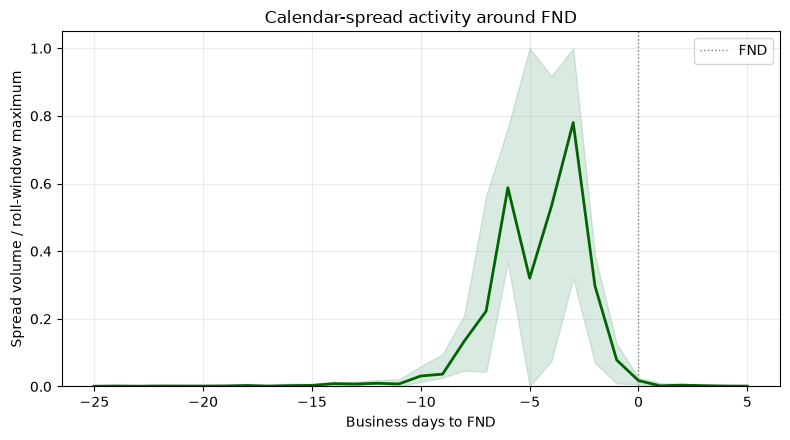

,bdays_to_fnd,median,q25,q75
0,-25,0.000819,0.000366,0.001871
1,-24,0.001388,0.000556,0.002809
2,-23,0.000958,0.000034,0.002196
3,-22,0.001509,0.000814,0.002778
4,-21,0.001348,0.000631,0.002038
5,-20,0.001330,0.000630,0.003751
6,-19,0.001676,0.000906,0.003311
7,-18,0.002987,0.001346,0.004547
8,-17,0.001311,0.000007,0.004510
9,-16,0.002526,0.001477,0.009008


In [3]:
panel['spread_volume_index'] = panel.groupby('roll_id')['spread_volume'].transform(
    lambda x: x / x.max() if x.max() > 0 else np.nan)
spread_curve = (panel.groupby('bdays_to_fnd')['spread_volume_index']
    .agg(median='median', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)).reset_index())
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(spread_curve['bdays_to_fnd'], spread_curve['median'], color='darkgreen', lw=2)
ax.fill_between(spread_curve['bdays_to_fnd'], spread_curve['q25'], spread_curve['q75'], color='seagreen', alpha=0.18)
ax.axvline(0, color='gray', ls=':', lw=1, label='FND')
ax.set(title='Calendar-spread activity around FND', xlabel='Business days to FND', ylabel='Spread volume / roll-window maximum', ylim=(0, 1.05))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()
spread_curve

## 3. Roll-level crossover timing

For this descriptive table, crossover means the first observed share strictly above 50%. The next notebook formalizes the event definition and produces the target table.

In [4]:
roll_summary = []
for roll_id, grp in panel.groupby('roll_id'):
    grp = grp.sort_values('bdays_to_fnd')
    vol_hits = grp.loc[grp['next_volume_share'] > 0.5]
    oi_hits = grp.loc[grp['next_oi_share'] > 0.5]
    roll_summary.append({
        'roll_id': roll_id,
        'volume_crossover_bdays_to_fnd': vol_hits.iloc[0]['bdays_to_fnd'] if len(vol_hits) else np.nan,
        'oi_crossover_bdays_to_fnd': oi_hits.iloc[0]['bdays_to_fnd'] if len(oi_hits) else np.nan,
        'max_spread_volume': grp['spread_volume'].max(),
    })
roll_summary = pd.DataFrame(roll_summary).sort_values('roll_id')
display(roll_summary)
print('Median volume-crossover timing:', roll_summary['volume_crossover_bdays_to_fnd'].median())
print('Rolls with OI crossover:', roll_summary['oi_crossover_bdays_to_fnd'].notna().sum(), '/', len(roll_summary))

,roll_id,volume_crossover_bdays_to_fnd,oi_crossover_bdays_to_fnd,max_spread_volume
0,ZNH0->ZNM0,-1,-2,2181870
1,ZNH1->ZNM1,-1,-2,2400665
2,ZNH2->ZNM2,-2,-3,2219653
3,ZNH3->ZNM3,-2,-4,2474634
4,ZNH4->ZNM4,-1,-4,3894122
5,ZNH5->ZNM5,-2,-3,3524683
6,ZNH6->ZNM6,-2,-2,4084999
7,ZNM0->ZNU0,-1,-2,2390678
8,ZNM1->ZNU1,-3,-4,2896100
9,ZNM2->ZNU2,-3,-4,2109845


Median volume-crossover timing: -2.0
Rolls with OI crossover: 27 / 27
